In [1]:
# --------------------------------------------------
# LINEAR REGRESSION ASSUMPTIONS PROJECT
# --------------------------------------------------

# Import pandas for working with data
import pandas as pd

# Import numpy for calculations
import numpy as np

# Import matplotlib for plots
import matplotlib.pyplot as plt

# Import seaborn for visualization
import seaborn as sns

# Import linear regression model
from sklearn.linear_model import LinearRegression

# Import Q-Q plot tool
import scipy.stats as stats

In [2]:
# --------------------------------------------------
# LOAD DATASET
# --------------------------------------------------

# Load your dataset
data = pd.read_csv(
    r'D:\MiniForge\Ex_Files_Intro_to_Data_Science\Ex_Files_Intro_to_Data_Science\Exercise Files\marketing_sales_data.csv'
)

# Display first 5 rows
data.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


In [3]:
# --------------------------------------------------
# CHECK COLUMN NAMES
# --------------------------------------------------

# Display exact column names
data.columns.tolist()

['TV', 'Radio', 'Social Media', 'Influencer', 'Sales']

In [4]:
# --------------------------------------------------
# SELECT FEATURES (X) AND TARGET (y)
# --------------------------------------------------

# Independent variables / features
X = data[['TV', 'Radio']]

# Dependent variable / target
y = data['Sales']

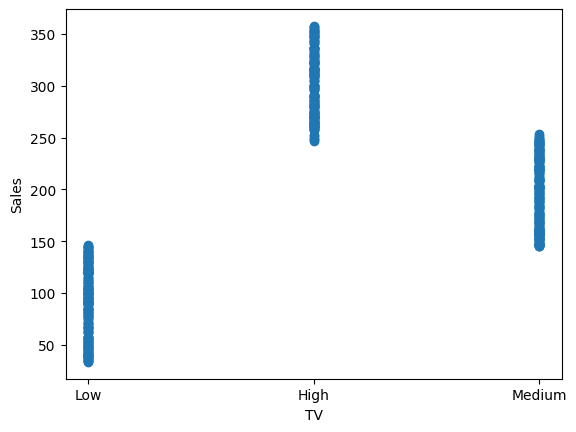

In [5]:
# --------------------------------------------------
# CHECK ASSUMPTION 1: LINEARITY
# --------------------------------------------------

# Scatterplot of TV advertising and Sales
plt.scatter(data['TV'], data['Sales'])

# Label x-axis
plt.xlabel('TV')

# Label y-axis
plt.ylabel('Sales')

# Display plot
plt.show()

In [7]:
# --------------------------------------------------
# CHECK DATA TYPES
# --------------------------------------------------

X.info()

<class 'pandas.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      572 non-null    str    
 1   Radio   572 non-null    float64
dtypes: float64(1), str(1)
memory usage: 9.1 KB


In [9]:
# Display column names
data.columns.tolist()

['TV', 'Radio', 'Social Media', 'Influencer', 'Sales']

In [10]:
# --------------------------------------------------
# CONVERT TV COLUMN TO NUMERIC
# --------------------------------------------------

# Convert TV column to numeric
data['TV'] = pd.to_numeric(
    data['TV'],
    errors='coerce'
)

# Check data types again
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            0 non-null      float64
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    str    
 4   Sales         572 non-null    float64
dtypes: float64(4), str(1)
memory usage: 22.5 KB


In [11]:
# --------------------------------------------------
# REMOVE MISSING VALUES
# --------------------------------------------------

data = data.dropna()

In [12]:
# --------------------------------------------------
# SELECT FEATURES AND TARGET
# --------------------------------------------------

X = data[['TV', 'Radio']]

y = data['Sales']

In [14]:
# --------------------------------------------------
# CLEAN AND PREPARE DATA
# --------------------------------------------------

# Convert TV to numeric because it was stored as text
data['TV'] = pd.to_numeric(
    data['TV'],
    errors='coerce'
)

# Convert Sales to numeric
data['Sales'] = pd.to_numeric(
    data['Sales'],
    errors='coerce'
)

# Remove rows with missing values
data = data.dropna()

In [15]:
# --------------------------------------------------
# SELECT FEATURES AND TARGET
# --------------------------------------------------

# Features
X = data[['TV', 'Radio']]

# Target
y = data['Sales']

In [16]:
# --------------------------------------------------
# CHECK SHAPES
# --------------------------------------------------

X.shape, y.shape

((0, 2), (0,))

In [18]:
# --------------------------------------------------
# CLEAN AND PREPARE MARKETING SALES DATA
# --------------------------------------------------

# Convert TV, Radio, and Sales to numeric
data['TV'] = pd.to_numeric(data['TV'], errors='coerce')
data['Radio'] = pd.to_numeric(data['Radio'], errors='coerce')
data['Sales'] = pd.to_numeric(data['Sales'], errors='coerce')

# Remove rows with missing values after conversion
data = data.dropna()

In [19]:
# --------------------------------------------------
# SELECT FEATURES AND TARGET
# --------------------------------------------------

# Features must be numeric only
X = data[['TV', 'Radio']]

# Target
y = data['Sales']

In [21]:
# --------------------------------------------------
# RELOAD DATASET FRESH
# --------------------------------------------------

data = pd.read_csv(
    r'D:\MiniForge\Ex_Files_Intro_to_Data_Science\Ex_Files_Intro_to_Data_Science\Exercise Files\marketing_sales_data.csv'
)

data.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


In [22]:
# --------------------------------------------------
# USE ONLY NUMERIC COLUMNS
# --------------------------------------------------

# Automatically keep only numeric columns
numeric_data = data.select_dtypes(include='number')

# Display numeric columns
numeric_data.columns.tolist()

['Radio', 'Social Media', 'Sales']

In [23]:
# --------------------------------------------------
# SELECT FEATURES AND TARGET
# --------------------------------------------------

X = numeric_data.drop(columns='Sales')

y = numeric_data['Sales']

X.shape, y.shape

((572, 2), (572,))

In [24]:
# --------------------------------------------------
# BUILD MODEL
# --------------------------------------------------

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
# --------------------------------------------------
# MAKE PREDICTIONS
# --------------------------------------------------

predictions = model.predict(X)

predictions[:5]

array([ 73.18922579, 108.33325795, 212.51262653, 210.67371873,
       306.82979169])

In [26]:
# --------------------------------------------------
# DISPLAY COEFFICIENTS
# --------------------------------------------------

print("Intercept:", model.intercept_)

print("Coefficients:", model.coef_)

Intercept: 43.80995594956994
Coefficients: [8.28430423 0.10223717]


In [27]:
# --------------------------------------------------
# MATCH COEFFICIENTS TO FEATURES
# --------------------------------------------------

pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

,Feature,Coefficient
0,Radio,8.284304
1,Social Media,0.102237


In [28]:
# --------------------------------------------------
# CHECK MODEL SCORE (R²)
# --------------------------------------------------

model.score(X, y)

0.7362301370566556